<a href="https://colab.research.google.com/github/zackdihel/ECON-5200-Data-Analytics/blob/main/Assignment%205/Assignment_5_The_Sovereign_Risk_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score, recall_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,roc_curve, auc, precision_recall_curve, average_precision_score)

import wbgapi as wb

In [83]:
# WDI indicator codes for our predictors
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

In [84]:
def fetch_wdi_data(indicators: dict, start_year: int = 2013, end_year: int = 2019) -> pd.DataFrame:
    frames = []

    for code, name in indicators.items():
        try:
            df = wb.data.DataFrame(
                code,
                time=range(start_year, end_year + 1),
                labels=True,          # include country names
                numericTimeKeys=True
            )
            # wbgapi returns countries as index, years as columns
            df = df.reset_index().melt(
                id_vars=['Country'],
                var_name='year',
                value_name=name
            )
            df = df.rename(columns={'Country': 'country'})
            frames.append(df)
            print(f"  ✓ {name}")
        except Exception as e:
            print(f"  ✗ {name} ({code}): {e}")

    if not frames:
        raise RuntimeError("No data fetched — check indicator codes or internet connection.")

    # Merge all indicators on country + year
    raw_df = frames[0]
    for frame in frames[1:]:
        raw_df = raw_df.merge(frame, on=['country', 'year'], how='outer')

    print(f"\nRaw panel shape: {raw_df.shape[0]} rows × {raw_df.shape[1]} columns")
    return raw_df

In [85]:
def clean_country_panel(df: pd.DataFrame, threshold: float = 0.4) -> pd.DataFrame:
    # Collapse to country-level means
    # Assumes df has a 'country' column; if it's already the index, skip groupby
    if 'country' in df.columns:
        country_df = df.groupby('country').mean(numeric_only=True)
    else:
        country_df = df.groupby(df.index).mean(numeric_only=True)

    n_countries, n_indicators = country_df.shape
    print(f"Starting shape: {n_countries} countries × {n_indicators} indicators")

    # Drop countries missing > 40% of indicators
    country_missing_frac = country_df.isnull().mean(axis=1)  # per-row (country)
    countries_to_keep = country_missing_frac[country_missing_frac <= threshold].index
    country_df = country_df.loc[countries_to_keep]
    print(f"After dropping sparse countries: {country_df.shape[0]} countries remain "
          f"({n_countries - country_df.shape[0]} dropped)")

    # Drop indicators missing > 40% of countries
    indicator_missing_frac = country_df.isnull().mean(axis=0)  # per-column (indicator)
    indicators_to_keep = indicator_missing_frac[indicator_missing_frac <= threshold].index
    country_df = country_df[indicators_to_keep]
    print(f"After dropping sparse indicators: {country_df.shape[1]} indicators remain "
          f"({n_indicators - country_df.shape[1]} dropped)")

    # Median-impute remaining gaps
    medians = country_df.median()
    country_df = country_df.fillna(medians)
    remaining_nulls = country_df.isnull().sum().sum()
    print(f"After median imputation: {remaining_nulls} nulls remaining")

    return country_df

In [86]:
raw_df = fetch_wdi_data(INDICATORS, start_year=2013, end_year=2019)

  ✓ gdp_growth_pc
  ✓ trade_pct_gdp
  ✓ fdi_inflows_pct_gdp
  ✓ tariff_rate_avg
  ✓ royalties_receipts
  ✓ inflation_cpi
  ✓ govt_debt_pct_gdp
  ✓ govt_expenditure_pct_gdp
  ✓ current_account_pct_gdp
  ✓ real_interest_rate
  ✓ exchange_rate_official
  ✓ secondary_enrollment_gross
  ✓ tertiary_enrollment_gross
  ✓ adult_literacy_rate
  ✓ education_expenditure_pct_gdp
  ✓ unemployment_rate
  ✓ internet_users_pct
  ✓ mobile_subscriptions_per100
  ✓ electricity_access_pct
  ✗ paved_roads_pct (IS.ROD.PAVE.ZS): APIError: JSON decoding error (https://api.worldbank.org/v2/en/sources/2/series/IS.ROD.PAVE.ZS/country/all/time/YR2013;YR2014;YR2015;YR2016;YR2017;YR2018;YR2019?per_page=1000&page=1&format=json)
  ✓ life_expectancy
  ✓ infant_mortality_per1000
  ✓ population_growth
  ✓ urbanization_pct
  ✓ health_expenditure_pct_gdp
  ✓ domestic_credit_pct_gdp
  ✓ market_cap_pct_gdp
  ✓ atms_per100k
  ✓ private_credit_pct_gdp
  ✓ natural_resource_rents_pct_gdp
  ✓ renewable_energy_pct
  ✗ co2_emission

In [87]:
clean_df = clean_country_panel(raw_df)

Starting shape: 266 countries × 0 indicators
After dropping sparse countries: 0 countries remain (266 dropped)
After dropping sparse indicators: 0 indicators remain (0 dropped)
After median imputation: 0.0 nulls remaining


In [88]:
# Run these to see what we're working with
print(raw_df.dtypes)
print(raw_df.head())
print(raw_df.shape)

country                           object
year                              object
gdp_growth_pc                     object
trade_pct_gdp                     object
fdi_inflows_pct_gdp               object
tariff_rate_avg                   object
royalties_receipts                object
inflation_cpi                     object
govt_debt_pct_gdp                 object
govt_expenditure_pct_gdp          object
current_account_pct_gdp           object
real_interest_rate                object
exchange_rate_official            object
secondary_enrollment_gross        object
tertiary_enrollment_gross         object
adult_literacy_rate               object
education_expenditure_pct_gdp     object
unemployment_rate                 object
internet_users_pct                object
mobile_subscriptions_per100       object
electricity_access_pct            object
life_expectancy                   object
infant_mortality_per1000          object
population_growth                 object
urbanization_pct

In [89]:
indicator_cols = [c for c in raw_df.columns if c not in ('country', 'year')]
raw_df[indicator_cols] = raw_df[indicator_cols].apply(pd.to_numeric, errors='coerce')
raw_df['year'] = pd.to_numeric(raw_df['year'], errors='coerce')

In [90]:
clean_df = clean_country_panel(raw_df)

Starting shape: 266 countries × 36 indicators
After dropping sparse countries: 238 countries remain (28 dropped)
After dropping sparse indicators: 29 indicators remain (7 dropped)
After median imputation: 0 nulls remaining


In [91]:
#define continuous outcome for gdp_growth_pc
y = clean_df['gdp_growth_pc']
X = clean_df.drop(columns=['gdp_growth_pc'])

print(f"y shape: {y.shape}")
print(f"X shape: {X.shape}")
print(f"\ny summary:\n{y.describe().round(3)}")

y shape: (238,)
X shape: (238, 28)

y summary:
count    238.000
mean       1.764
std        2.447
min      -12.547
25%        0.569
50%        1.798
75%        3.299
max        7.388
Name: gdp_growth_pc, dtype: float64


In [92]:
#define binary crisis outcome
crisis = (clean_df['gdp_growth_pc'] < 0).astype(int)

print(f"Crisis countries:     {crisis.sum()} ({crisis.mean()*100:.1f}%)")
print(f"Non-crisis countries: {(crisis == 0).sum()} ({(crisis == 0).mean()*100:.1f}%)")
print(f"\nCrisis countries list:\n{crisis[crisis == 1].index.tolist()}")

y      = clean_df['gdp_growth_pc']   # continuous
crisis = (y < 0).astype(int)         # binary
X      = clean_df.drop(columns=['gdp_growth_pc'])

Crisis countries:     38 (16.0%)
Non-crisis countries: 200 (84.0%)

Crisis countries list:
['Afghanistan', 'Angola', 'Argentina', 'Bahamas, The', 'Barbados', 'Belize', 'Bermuda', 'Brazil', 'Brunei Darussalam', 'Caribbean small states', 'Central African Republic', 'Chad', 'Congo, Rep.', 'Equatorial Guinea', 'Fragile and conflict affected situations', 'Iran, Islamic Rep.', 'Jordan', 'Kuwait', 'Latin America & Caribbean', 'Latin America & the Caribbean (IDA & IBRD countries)', 'Lebanon', 'Lesotho', 'Liberia', 'Libya', 'Low income', 'Macao SAR, China', 'Namibia', 'Oman', 'Qatar', 'Solomon Islands', 'South Africa', 'Sudan', 'Suriname', 'Trinidad and Tobago', 'Ukraine', 'United Arab Emirates', 'Venezuela, RB', 'Yemen, Rep.']


In [93]:
# Rebuild clean_df from raw_df
raw_df_copy = raw_df.copy()
indicator_cols = [c for c in raw_df_copy.columns if c not in ('country', 'year')]
raw_df_copy[indicator_cols] = raw_df_copy[indicator_cols].apply(pd.to_numeric, errors='coerce')
raw_df_copy['year'] = pd.to_numeric(raw_df_copy['year'], errors='coerce')

clean_df = clean_country_panel(raw_df_copy)

# Filter aggregates
economy_df   = pd.DataFrame(wb.economy.list()).set_index('id')
country_only = economy_df[economy_df['aggregate'] == False]
name_to_iso  = {row['value']: iso for iso, row in country_only.iterrows()}

clean_df['iso3']  = clean_df.index.map(name_to_iso)
print(f"Matched: {clean_df['iso3'].notna().sum()} / {len(clean_df)}")

actual_countries = clean_df[clean_df['iso3'].notna()].index
clean_df = clean_df.loc[actual_countries].drop(columns=['iso3'])

# Outcomes
y      = clean_df['gdp_growth_pc']
crisis = (y < 0).astype(int)
X      = clean_df.drop(columns=['gdp_growth_pc'])

print(f"\nClean country count:  {len(clean_df)}")
print(f"Crisis countries:     {crisis.sum()} ({crisis.mean()*100:.1f}%)")
print(f"Non-crisis countries: {(crisis == 0).sum()} ({(crisis == 0).mean()*100:.1f}%)")
print(f"\nCrisis countries list:\n{crisis[crisis == 1].index.tolist()}")

Starting shape: 266 countries × 36 indicators
After dropping sparse countries: 238 countries remain (28 dropped)
After dropping sparse indicators: 29 indicators remain (7 dropped)
After median imputation: 0 nulls remaining
Matched: 190 / 238

Clean country count:  190
Crisis countries:     33 (17.4%)
Non-crisis countries: 157 (82.6%)

Crisis countries list:
['Afghanistan', 'Angola', 'Argentina', 'Bahamas, The', 'Barbados', 'Belize', 'Bermuda', 'Brazil', 'Brunei Darussalam', 'Central African Republic', 'Chad', 'Congo, Rep.', 'Equatorial Guinea', 'Iran, Islamic Rep.', 'Jordan', 'Kuwait', 'Lebanon', 'Lesotho', 'Liberia', 'Libya', 'Macao SAR, China', 'Namibia', 'Oman', 'Qatar', 'Solomon Islands', 'South Africa', 'Sudan', 'Suriname', 'Trinidad and Tobago', 'Ukraine', 'United Arab Emirates', 'Venezuela, RB', 'Yemen, Rep.']


In [94]:

# 70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
crisis_train, crisis_test = crisis.loc[X_train.index], crisis.loc[X_test.index]

# Fit scaler on training data only, transform both
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    index=X_train.index,
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index,
    columns=X_test.columns
)

print(f"Train: {X_train_scaled.shape[0]} countries | Test: {X_test_scaled.shape[0]} countries")
print(f"Crisis in train: {crisis_train.sum()} ({crisis_train.mean()*100:.1f}%)")
print(f"Crisis in test:  {crisis_test.sum()} ({crisis_test.mean()*100:.1f}%)")

Train: 133 countries | Test: 57 countries
Crisis in train: 22 (16.5%)
Crisis in test:  11 (19.3%)


In [95]:
print("=" * 40)
print("DATASET SUMMARY")
print("=" * 40)
print(f"Total countries:    {len(X)}")
print(f"Total features:     {X.shape[1]}")
print(f"  Training set:     {X_train.shape[0]} countries")
print(f"  Test set:         {X_test.shape[0]} countries")
print(f"\nCrisis countries:     {crisis.sum()} ({crisis.mean()*100:.1f}%)")
print(f"Non-crisis countries: {(crisis==0).sum()} ({(crisis==0).mean()*100:.1f}%)")
print(f"\nCrisis base rate:   {crisis.mean():.3f}")
print("=" * 40)

DATASET SUMMARY
Total countries:    190
Total features:     28
  Training set:     133 countries
  Test set:         57 countries

Crisis countries:     33 (17.4%)
Non-crisis countries: 157 (82.6%)

Crisis base rate:   0.174


#**Phase 1: The Complexity Trap — OLS Failure and Regularization Rescue**

In [96]:
# Fit OLS
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

# Predict
y_pred_ols = ols.predict(X_test_scaled)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ols))
r2   = r2_score(y_test, y_pred_ols)

r2_train = r2_score(y_train, ols.predict(X_train_scaled))
r2_test  = r2_score(y_test,  y_pred_ols)

print("OLS R² DIAGNOSTICS")
print("=" * 40)
print(f"R² train:  {r2_train:.3f}")
print(f"R² test:   {r2_test:.3f}")
print(f"Gap:       {r2_train - r2_test:.3f}")
print("=" * 40)

OLS R² DIAGNOSTICS
R² train:  0.471
R² test:   0.349
Gap:       0.122


In [97]:
#p/n ratio
p = X_train_scaled.shape[1]  # number of predictors
n = X_train_scaled.shape[0]  # number of observations

print(f"Predictors (p):        {p}")
print(f"Observations (n):      {n}")
print(f"p/n ratio:             {p/n:.3f}")
print()

Predictors (p):        28
Observations (n):      133
p/n ratio:             0.211



The p/n ratio of 0.211 indicates that OLS is stretching out the number of predictors in order to fit the sample size of countries, so it is overfitting the predictors given the sample size; there are too many degrees of freedom for the model. R^2 for training is biased as a result of this overfitting. R^2 for testing is low-bias, but higher in variance due to how sensitive the data is to what countries are included in the sample.

In [98]:
# Ridge and Lasso

ridge_alphas = np.logspace(-3, 3, 100)
lasso_alphas = np.logspace(-3, 1, 100)

# RidgeCV
ridge = RidgeCV(alphas=ridge_alphas, cv=5, scoring='r2')
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)
r2_ridge_train = r2_score(y_train, ridge.predict(X_train_scaled))
r2_ridge_test  = r2_score(y_test, y_pred_ridge)
rmse_ridge     = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

# LassoCV
lasso = LassoCV(alphas=lasso_alphas, cv=5, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)
r2_lasso_train = r2_score(y_train, lasso.predict(X_train_scaled))
r2_lasso_test  = r2_score(y_test, y_pred_lasso)
rmse_lasso     = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

# Comparison table
print("MODEL COMPARISON")
print("=" * 60)
print(f"{'Model':<10} {'α':>8} {'R² Train':>10} {'R² Test':>10} {'Gap':>8} {'RMSE':>8}")
print("-" * 55)
print(f"{'OLS':<10} {'N/A':>8} {r2_train:>10.3f} {r2_test:>10.3f} {r2_train-r2_test:>8.3f} {rmse:>8.3f}")
print(f"{'Ridge':<10} {ridge.alpha_:>8.4f} {r2_ridge_train:>10.3f} {r2_ridge_test:>10.3f} {r2_ridge_train-r2_ridge_test:>8.3f} {rmse_ridge:>8.3f}")
print(f"{'Lasso':<10} {lasso.alpha_:>8.4f} {r2_lasso_train:>10.3f} {r2_lasso_test:>10.3f} {r2_lasso_train-r2_lasso_test:>8.3f} {rmse_lasso:>8.3f}")
print("=" * 60)

print(f"\nLasso zeroed out {(lasso.coef_ == 0).sum()} / {len(lasso.coef_)} predictors")

MODEL COMPARISON
Model             α   R² Train    R² Test      Gap     RMSE
-------------------------------------------------------
OLS             N/A      0.471      0.349    0.122    1.523
Ridge      123.2847      0.362      0.400   -0.038    1.463
Lasso        0.2915      0.353      0.309    0.044    1.569

Lasso zeroed out 22 / 28 predictors


In [99]:
comparison_df = pd.DataFrame([
    {
        'Model':     'OLS',
        'Alpha':     None,
        'R² Train':  round(r2_train, 3),
        'R² Test':   round(r2_test, 3),
        'Gap':       round(r2_train - r2_test, 3),
        'RMSE':      round(rmse, 3),
        'Non-Zero':  len(ols.coef_)
    },
    {
        'Model':     'Ridge',
        'Alpha':     round(ridge.alpha_, 4),
        'R² Train':  round(r2_ridge_train, 3),
        'R² Test':   round(r2_ridge_test, 3),
        'Gap':       round(r2_ridge_train - r2_ridge_test, 3),
        'RMSE':      round(rmse_ridge, 3),
        'Non-Zero':  int((ridge.coef_ != 0).sum())
    },
    {
        'Model':     'Lasso',
        'Alpha':     round(lasso.alpha_, 4),
        'R² Train':  round(r2_lasso_train, 3),
        'R² Test':   round(r2_lasso_test, 3),
        'Gap':       round(r2_lasso_train - r2_lasso_test, 3),
        'RMSE':      round(rmse_lasso, 3),
        'Non-Zero':  int((lasso.coef_ != 0).sum())
    }
]).set_index('Model')

print(comparison_df.to_string())

          Alpha  R² Train  R² Test    Gap   RMSE  Non-Zero
Model                                                     
OLS         NaN     0.471    0.349  0.122  1.523        28
Ridge  123.2847     0.362    0.400 -0.038  1.463        27
Lasso    0.2915     0.353    0.309  0.044  1.569         6


The recommended model as a result from this would be a Ridge model. The original OLS was overfitted, leading to a gap in R^2 train and R^2 test, but Ridge is the only approach that **improves** its fit from training to test. Ridge and Lasso are both introducing bias in order to push coefs to 0, which helps to regulate the variance that OLS had too much of.

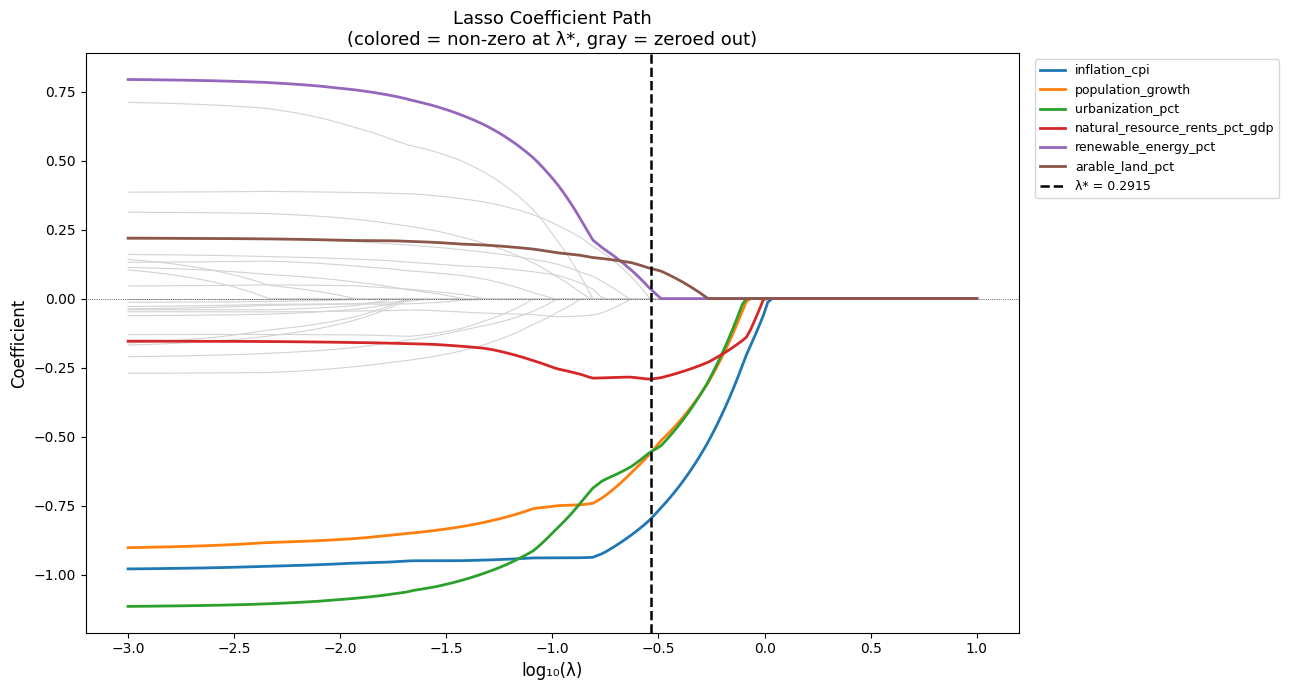


Non-zero predictors at λ* = 0.2915:
  inflation_cpi                       -0.7975
  population_growth                   -0.5578
  urbanization_pct                    -0.5546
  natural_resource_rents_pct_gdp      -0.2917
  arable_land_pct                     +0.1087
  renewable_energy_pct                +0.0330


In [100]:
# Lasso path

fig, ax = plt.subplots(figsize=(13, 7))

alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train,
    alphas=np.logspace(1, -3, 200),
    max_iter=10000
)

# nonzero predictors at alpha
nonzero_mask = lasso.coef_ != 0
cv_alpha_log = np.log10(lasso.alpha_)

for i, col in enumerate(X.columns):
    if nonzero_mask[i]:
        ax.plot(np.log10(alphas_path), coefs_path[i],
                linewidth=2, label=col, zorder=3)
    else:
        ax.plot(np.log10(alphas_path), coefs_path[i],
                linewidth=0.8, color='lightgray', zorder=1)

# Overlays
ax.axvline(cv_alpha_log, color='black', linestyle='--', linewidth=1.8,
           label=f'λ* = {lasso.alpha_:.4f}', zorder=4)
ax.axhline(0, color='black', linewidth=0.5, linestyle=':')

ax.set_xlabel('log₁₀(λ)', fontsize=12)
ax.set_ylabel('Coefficient', fontsize=12)
ax.set_title('Lasso Coefficient Path\n(colored = non-zero at λ*, gray = zeroed out)', fontsize=13)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9, frameon=True)
plt.tight_layout()
plt.show()

# Print surviving predictors
print(f"\nNon-zero predictors at λ* = {lasso.alpha_:.4f}:")
surviving = pd.Series(lasso.coef_, index=X.columns)
surviving = surviving[surviving != 0].sort_values(key=abs, ascending=False)
for feat, coef in surviving.items():
    print(f"  {feat:<35} {coef:+.4f}")

renewable_energy_pct is the first predictor to enter the model. A country's renewable energy infrastructure is a good indicator of broader institutional or industrial stability. A robust renewable energy sector likely means the country has the capacity for infrastructure investment, which bodes well for their development status.

Life expectancy should not be disregard just because it is zeroed out in the Lass model. Lasso zeros out variables that do not have strong *predictive* tendency for what we're testing. For the likely correlation structure of the data in the model, life expectancy is almost definitely highly correlated to a number of the nonzero predictors Lasso ended on. It is a variable made redundant by what else is included, which does not mean it should be de-prioritized.

# **Phase 2: The Crisis Classifier — From Forecasting to Classification**

In [101]:
# Lasso-selected features
lasso_features = surviving.index.tolist()
print(f"Lasso-selected features ({len(lasso_features)}):")
for f in lasso_features:
    print(f"  - {f}")

# Subset to Lasso features
X_train_lasso = X_train_scaled[lasso_features]
X_test_lasso  = X_test_scaled[lasso_features]

# Fit LPM
lpm = LinearRegression()
lpm.fit(X_train_lasso, crisis_train)

# Predictions
lpm_pred_prob = lpm.predict(X_test_scaled[lasso_features])
lpm_pred_class = (lpm_pred_prob >= 0.5).astype(int)

# Coefficients
lpm_coef_df = pd.DataFrame({
    'Feature':     lasso_features,
    'Coefficient': lpm.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\nLPM Intercept: {lpm.intercept_:.4f}")
print(f"\nLPM Coefficients:")
print(lpm_coef_df.to_string(index=False))

# Out-of-sample predicted probabilities
print(f"\nPredicted probability range: [{lpm_pred_prob.min():.3f}, {lpm_pred_prob.max():.3f}]")
print(f"Predictions outside [0,1]:   {((lpm_pred_prob < 0) | (lpm_pred_prob > 1)).sum()}")

Lasso-selected features (6):
  - inflation_cpi
  - population_growth
  - urbanization_pct
  - natural_resource_rents_pct_gdp
  - arable_land_pct
  - renewable_energy_pct

LPM Intercept: 0.1654

LPM Coefficients:
                       Feature  Coefficient
             population_growth     0.115306
          renewable_energy_pct    -0.105573
                 inflation_cpi     0.069295
natural_resource_rents_pct_gdp     0.046985
              urbanization_pct     0.035829
               arable_land_pct    -0.012590

Predicted probability range: [-0.101, 0.553]
Predictions outside [0,1]:   5


Based on the LPM, the countries that are outside [0,1] are illogical. Given that the upper limit of our probability range is 0.553, that means 5 countries are being given a negative probability of crisis, which does not make any sense in practice. The baseline probability of a crisis shoudl always be >0, otherwise the data is not usable in any pracitcal sense.

In [102]:
# Fit Logistic Regression
logit = LogisticRegression(penalty=None, max_iter=1000, random_state=42)
logit.fit(X_train_lasso, crisis_train)

# Predicted probabilities
logit_pred_prob  = logit.predict_proba(X_test_lasso)[:, 1]
logit_pred_class = logit.predict(X_test_lasso)

# Coefficients
logit_coef_df = pd.DataFrame({
    'Feature':     lasso_features,
    'Coefficient': logit.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"Intercept (β₀): {logit.intercept_[0]:.4f}")
print(f"\nCoefficients:")
print(logit_coef_df.to_string(index=False))


Intercept (β₀): -2.1927

Coefficients:
                       Feature  Coefficient
             population_growth     0.993191
          renewable_energy_pct    -0.917860
                 inflation_cpi     0.465762
               arable_land_pct    -0.243903
              urbanization_pct     0.220081
natural_resource_rents_pct_gdp     0.171308


In [103]:
# Odds Ratios
odds_ratio_df = pd.DataFrame({
    'Feature':     lasso_features,
    'Beta':        logit.coef_[0],
    'Odds Ratio':  np.exp(logit.coef_[0])
})
odds_ratio_df['Abs OR Distance from 1'] = abs(odds_ratio_df['Odds Ratio'] - 1)
odds_ratio_df = odds_ratio_df.sort_values('Abs OR Distance from 1', ascending=False)
odds_ratio_df = odds_ratio_df.drop(columns='Abs OR Distance from 1').round(4)

print("LOGISTIC REGRESSION COEFFICIENTS & ODDS RATIOS")
print("=" * 55)
print(f"Intercept (β₀): {logit.intercept_[0]:.4f}  |  OR: {np.exp(logit.intercept_[0]):.4f}")
print()
print(odds_ratio_df.to_string(index=False))


LOGISTIC REGRESSION COEFFICIENTS & ODDS RATIOS
Intercept (β₀): -2.1927  |  OR: 0.1116

                       Feature    Beta  Odds Ratio
             population_growth  0.9932      2.6998
          renewable_energy_pct -0.9179      0.3994
                 inflation_cpi  0.4658      1.5932
              urbanization_pct  0.2201      1.2462
               arable_land_pct -0.2439      0.7836
natural_resource_rents_pct_gdp  0.1713      1.1869


In [104]:
print(f"\nPREDICTED PROBABILITY BOUNDS")
print("=" * 55)
print(f"Min probability:             {logit_pred_prob.min():.6f}")
print(f"Max probability:             {logit_pred_prob.max():.6f}")
print(f"Predictions outside [0,1]:   {((logit_pred_prob < 0) | (logit_pred_prob > 1)).sum()}")


PREDICTED PROBABILITY BOUNDS
Min probability:             0.011925
Max probability:             0.716870
Predictions outside [0,1]:   0


The highest OR from our variables is population growth, at 2.6998. One standard deviation increase in population increases a country's odds of crisis roughly 2.7x.

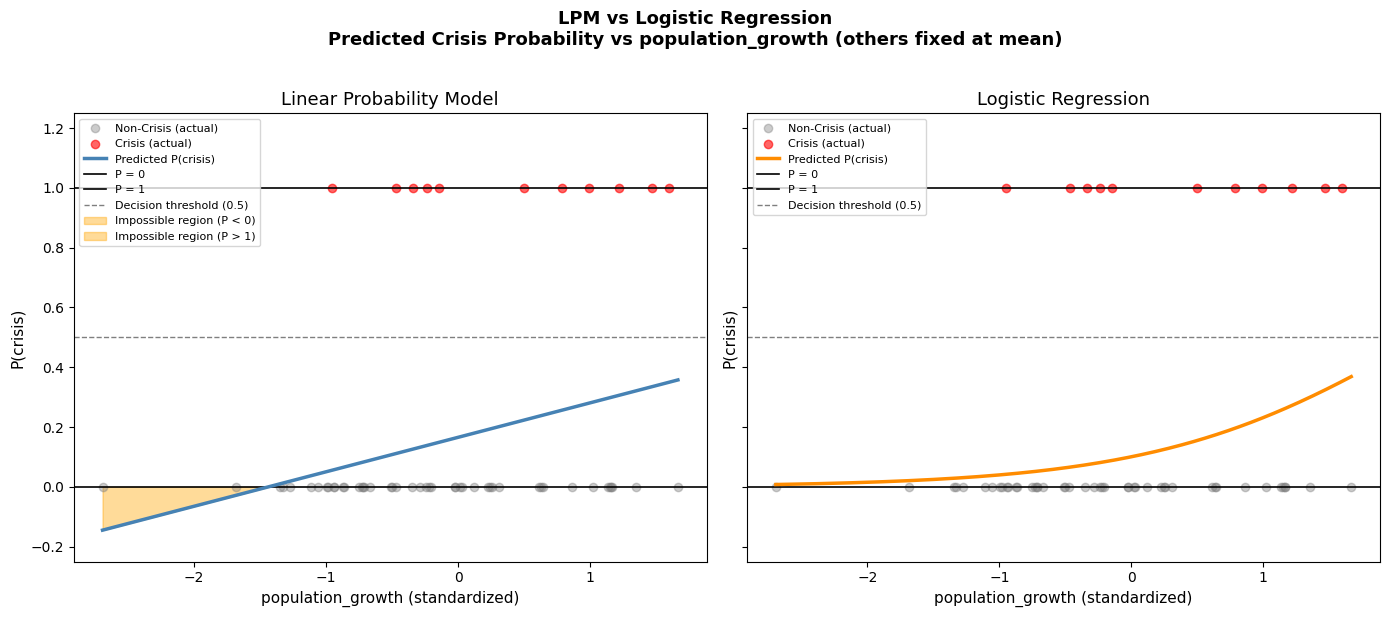

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

models = [
    ('Linear Probability Model', lpm_grid_prob,   'steelblue'),
    ('Logistic Regression',      logit_grid_prob,  'darkorange'),
]

for i, (ax, (title, pred_prob, color)) in enumerate(zip(axes, models)):
    # Actual outcomes as background scatter
    ax.scatter(X_test_scaled[strongest_feature][crisis_test == 0],
               np.zeros((crisis_test == 0).sum()),
               alpha=0.4, color='gray', label='Non-Crisis (actual)', zorder=2)
    ax.scatter(X_test_scaled[strongest_feature][crisis_test == 1],
               np.ones((crisis_test == 1).sum()),
               alpha=0.6, color='red', label='Crisis (actual)', zorder=2)

    # Smooth predicted curve
    ax.plot(x_grid, pred_prob, color=color, linewidth=2.5,
            label='Predicted P(crisis)', zorder=3)

    # Reference lines at P=0 and P=1
    ax.axhline(0,   color='black', linestyle='-',  linewidth=1.2, label='P = 0')
    ax.axhline(1,   color='black', linestyle='-',  linewidth=1.2, label='P = 1')
    ax.axhline(0.5, color='black', linestyle='--', linewidth=1,
               alpha=0.5, label='Decision threshold (0.5)')

    # shade impossible regions
    if i == 0:
        ax.fill_between(x_grid, pred_prob, 0,
                        where=(pred_prob < 0),
                        color='orange', alpha=0.4, label='Impossible region (P < 0)', zorder=1)
        ax.fill_between(x_grid, pred_prob, 1,
                        where=(pred_prob > 1),
                        color='orange', alpha=0.4, label='Impossible region (P > 1)', zorder=1)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel(f'{strongest_feature} (standardized)', fontsize=11)
    ax.set_ylabel('P(crisis)', fontsize=11)
    ax.legend(fontsize=8)
    ax.set_ylim(-0.25, 1.25)

plt.suptitle(f'LPM vs Logistic Regression\nPredicted Crisis Probability vs {strongest_feature} (others fixed at mean)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# **Phase 3: Operational Deployment — Metrics That Matter**

In [106]:
# Base rate and naive baseline
test_base_rate = crisis_test.mean()
naive_accuracy = (crisis_test == 0).mean()

print("NAIVE BASELINE DIAGNOSTICS")
print("=" * 40)
print(f"Test set size:        {len(crisis_test)}")
print(f"Crisis countries:     {crisis_test.sum()}")
print(f"Non-crisis countries: {(crisis_test == 0).sum()}")
print(f"Crisis base rate:     {test_base_rate:.3f} ({test_base_rate*100:.1f}%)")
print(f"\nNaïve baseline accuracy: {naive_accuracy:.3f} ({naive_accuracy*100:.1f}%)")

NAIVE BASELINE DIAGNOSTICS
Test set size:        57
Crisis countries:     11
Non-crisis countries: 46
Crisis base rate:     0.193 (19.3%)

Naïve baseline accuracy: 0.807 (80.7%)


In [107]:
# Predictions at default threshold
logit_pred_class_05 = (logit_pred_prob >= 0.5).astype(int)

accuracy_05 = accuracy_score(crisis_test, logit_pred_class_05)
recall_05   = recall_score(crisis_test, logit_pred_class_05)

print("LOGISTIC REGRESSION AT τ = 0.5")
print("=" * 40)
print(f"Accuracy:  {accuracy_05:.3f} ({accuracy_05*100:.1f}%)")
print(f"Recall:    {recall_05:.3f} ({recall_05*100:.1f}%)")
print(f"\nCrisis countries in test:    {crisis_test.sum()}")
print(f"Correctly flagged (TP):      {(logit_pred_class_05 & crisis_test).sum()}")
print(f"Missed crisis countries:     {((1 - logit_pred_class_05) & crisis_test).sum()}")

LOGISTIC REGRESSION AT τ = 0.5
Accuracy:  0.807 (80.7%)
Recall:    0.091 (9.1%)

Crisis countries in test:    11
Correctly flagged (TP):      1
Missed crisis countries:     10


Not impressed, the accuracy paradox is that based on our sample we are not correctly identifying the false negatives (missing a crisis country) and false positives (flagging a non-crisis country). When thinking about accuracy, a false negative and a flase positive are given the same conclusion: they are both inaccurate. However recall is showing us that the difference between a false negative and false positive matters significantly, as a missed crisis is a massive oversight for the model.

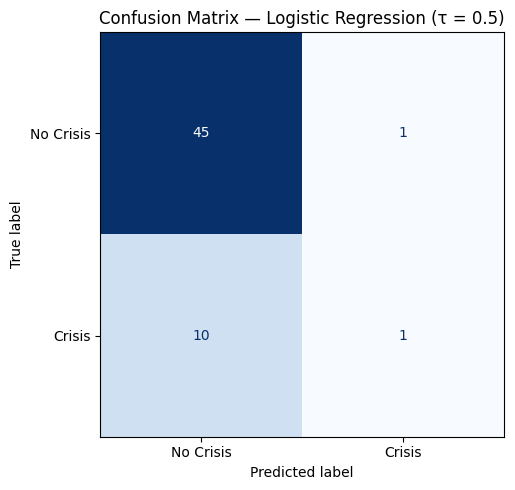

CLASSIFICATION REPORT (τ = 0.5)
              precision    recall  f1-score   support

   No Crisis       0.82      0.98      0.89        46
      Crisis       0.50      0.09      0.15        11

    accuracy                           0.81        57
   macro avg       0.66      0.53      0.52        57
weighted avg       0.76      0.81      0.75        57

MANUAL BREAKDOWN
True Negatives  (correctly called non-crisis): 45
False Positives (wrongly flagged as crisis):   1
False Negatives (missed crisis countries):     10
True Positives  (correctly flagged crisis):    1


In [108]:
# Confusion matrix
cm = confusion_matrix(crisis_test, logit_pred_class_05)

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Crisis', 'Crisis'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression (τ = 0.5)', fontsize=12)
plt.tight_layout()
plt.show()

# Classification report
print("CLASSIFICATION REPORT (τ = 0.5)")
print("=" * 50)
print(classification_report(crisis_test, logit_pred_class_05,
                            target_names=['No Crisis', 'Crisis']))

# Manual breakdown for clarity
tn, fp, fn, tp = cm.ravel()
print("MANUAL BREAKDOWN")
print("=" * 50)
print(f"True Negatives  (correctly called non-crisis): {tn}")
print(f"False Positives (wrongly flagged as crisis):   {fp}")
print(f"False Negatives (missed crisis countries):     {fn}")
print(f"True Positives  (correctly flagged crisis):    {tp}")

A false negative is far more costly than a false positive in this context. The cost of a false positive would be something like incorrect infusion of debt, or financial levers being pulled for a country that does not need them. A false negative would result in a country in need of monetory or financial assistance being ignored, and any crisis occurring undoubtedly worsening and possibly spilling over. Therefore, recall should be emphasized over accuracy.

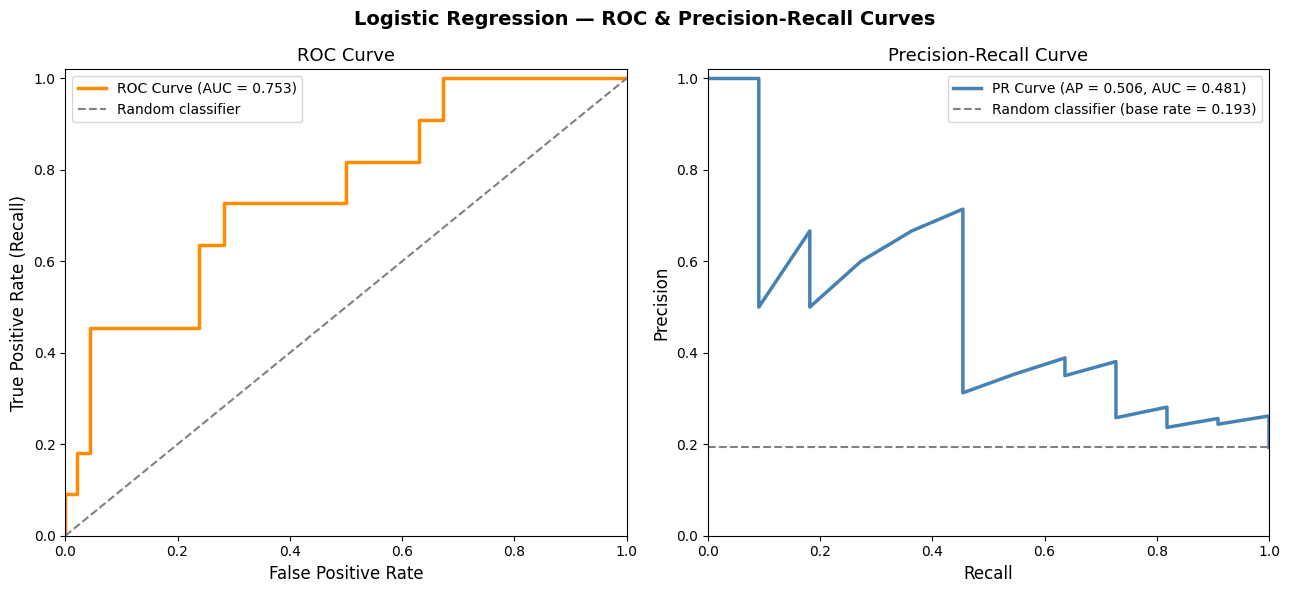

ROC-AUC:           0.753
Average Precision: 0.506
PR-AUC:            0.481


In [110]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Calculate ROC curve and AUC
fpr, tpr, roc_thresholds = roc_curve(crisis_test, logit_pred_prob)
roc_auc = auc(fpr, tpr)

# Calculate Precision-Recall curve and Average Precision
precision, recall, pr_thresholds = precision_recall_curve(crisis_test, logit_pred_prob)
avg_precision = average_precision_score(crisis_test, logit_pred_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', linewidth=2.5,
             label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--',
             linewidth=1.5, label='Random classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# Precision-Recall Curve
pr_auc = auc(recall, precision)
axes[1].plot(recall, precision, color='steelblue', linewidth=2.5,
             label=f'PR Curve (AP = {avg_precision:.3f}, AUC = {pr_auc:.3f})')
axes[1].axhline(test_base_rate, color='gray', linestyle='--',
                linewidth=1.5, label=f'Random classifier (base rate = {test_base_rate:.3f})')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle('Logistic Regression — ROC & Precision-Recall Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"ROC-AUC:           {roc_auc:.3f}")
print(f"Average Precision: {avg_precision:.3f}")
print(f"PR-AUC:            {pr_auc:.3f}")

The ROC-AUC of 0.753 is higher than PR-AUC of 0.481 mainly due to the fact that ROC is incorporating the true negatives from the sample into its calculation. The number of true negatives is somewhat inflating the results shown for ROC. PR on the other hand does not improve from correctly predicting non-crises, it is only sensitive to crisis detection. Therefore PR is a more informative curve for this example.

In [111]:
#threshold analysis
thresholds = np.arange(0.01, 1.00, 0.01)

results = []
for tau in thresholds:
    flagged     = (logit_pred_prob >= tau).sum()
    predicted   = (logit_pred_prob >= tau).astype(int)
    tp          = ((predicted == 1) & (crisis_test == 1)).sum()
    fp          = ((predicted == 1) & (crisis_test == 0)).sum()
    fn          = ((predicted == 0) & (crisis_test == 1)).sum()
    recall      = tp / crisis_test.sum()
    precision   = tp / flagged if flagged > 0 else 0
    accuracy    = accuracy_score(crisis_test, predicted)

    results.append({
        'threshold':  round(tau, 2),
        'flagged':    flagged,
        'TP':         tp,
        'FP':         fp,
        'FN':         fn,
        'recall':     round(recall, 3),
        'precision':  round(precision, 3),
        'accuracy':   round(accuracy, 3),
    })

results_df = pd.DataFrame(results)

# Lowest threshold that flags at most 5 countries
at_most_5 = results_df[results_df['flagged'] <= 5]
most_aggressive = at_most_5.loc[at_most_5['threshold'].idxmin()]

print("THRESHOLD SWEEP")
print("=" * 55)
print(f"Most aggressive threshold (≤5 flags): τ = {most_aggressive['threshold']}")
print(f"  Countries flagged: {most_aggressive['flagged']}")
print(f"  True Positives:    {most_aggressive['TP']}")
print(f"  False Positives:   {most_aggressive['FP']}")
print(f"  Recall:            {most_aggressive['recall']}")
print(f"  Precision:         {most_aggressive['precision']}")

# Full table
print(f"\nThreshold sweep (τ = 0.01 to 0.99):")
print(results_df[results_df['threshold'].between(0.01, 0.99)].to_string(index=False))

THRESHOLD SWEEP
Most aggressive threshold (≤5 flags): τ = 0.24
  Countries flagged: 5.0
  True Positives:    3.0
  False Positives:   2.0
  Recall:            0.273
  Precision:         0.6

Threshold sweep (τ = 0.01 to 0.99):
 threshold  flagged  TP  FP  FN  recall  precision  accuracy
      0.01       57  11  46   0   1.000      0.193     0.193
      0.02       54  11  43   0   1.000      0.204     0.246
      0.03       52  11  41   0   1.000      0.212     0.281
      0.04       46  11  35   0   1.000      0.239     0.386
      0.05       38   9  29   2   0.818      0.237     0.456
      0.06       30   8  22   3   0.727      0.267     0.561
      0.07       28   8  20   3   0.727      0.286     0.596
      0.08       24   8  16   3   0.727      0.333     0.667
      0.09       22   8  14   3   0.727      0.364     0.702
      0.10       20   7  13   4   0.636      0.350     0.702
      0.11       19   7  12   4   0.636      0.368     0.719
      0.12       17   6  11   5   0.545  

In [112]:
tau_optimal = 0.19
optimal = results_df[results_df['threshold'] == tau_optimal].iloc[0]

print("OPTIMAL THRESHOLD — CAPACITY CONSTRAINED")
print("=" * 45)
print(f"Threshold (τ):       {tau_optimal}")
print(f"Countries flagged:   {int(optimal['flagged'])}")
print(f"Precision:           {optimal['precision']:.3f}")
print(f"Recall:              {optimal['recall']:.3f}")

OPTIMAL THRESHOLD — CAPACITY CONSTRAINED
Threshold (τ):       0.19
Countries flagged:   7
Precision:           0.714
Recall:              0.455


In [113]:
# Add F1 to results_df
results_df['f1'] = (2 * results_df['precision'] * results_df['recall'] /
                    (results_df['precision'] + results_df['recall'])).fillna(0)

# F1-optimal threshold
f1_optimal = results_df.loc[results_df['f1'].idxmax()]

# Capacity-constrained threshold
tau_optimal = 0.19
capacity = results_df[results_df['threshold'] == tau_optimal].iloc[0]

print("THRESHOLD COMPARISON")
print("=" * 55)
print(f"{'Metric':<25} {'Capacity (τ=0.19)':>18} {'F1-Optimal':>12}")
print("-" * 55)
print(f"{'Threshold (τ)':<25} {capacity['threshold']:>18.2f} {f1_optimal['threshold']:>12.2f}")
print(f"{'Countries flagged':<25} {int(capacity['flagged']):>18} {int(f1_optimal['flagged']):>12}")
print(f"{'Precision':<25} {capacity['precision']:>18.3f} {f1_optimal['precision']:>12.3f}")
print(f"{'Recall':<25} {capacity['recall']:>18.3f} {f1_optimal['recall']:>12.3f}")
print(f"{'F1 Score':<25} {capacity['f1']:>18.3f} {f1_optimal['f1']:>12.3f}")
print(f"{'Accuracy':<25} {capacity['accuracy']:>18.3f} {f1_optimal['accuracy']:>12.3f}")

THRESHOLD COMPARISON
Metric                     Capacity (τ=0.19)   F1-Optimal
-------------------------------------------------------
Threshold (τ)                           0.19         0.19
Countries flagged                          7            7
Precision                              0.714        0.714
Recall                                 0.455        0.455
F1 Score                               0.556        0.556
Accuracy                               0.860        0.860


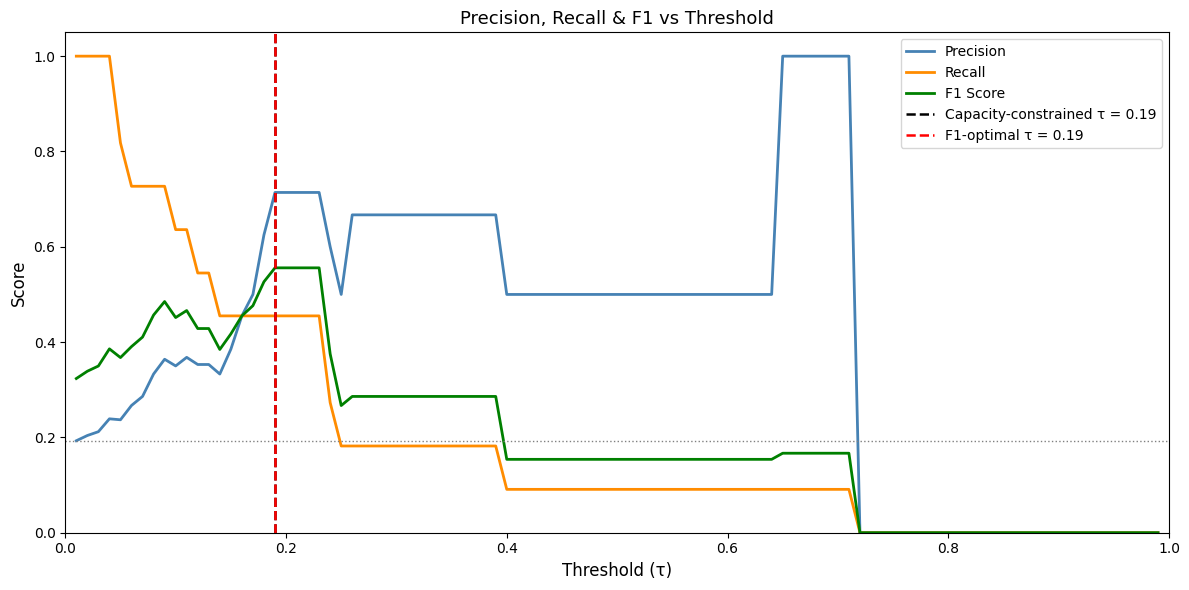

In [114]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(results_df['threshold'], results_df['precision'],
        color='steelblue', linewidth=2, label='Precision')
ax.plot(results_df['threshold'], results_df['recall'],
        color='darkorange', linewidth=2, label='Recall')
ax.plot(results_df['threshold'], results_df['f1'],
        color='green', linewidth=2, label='F1 Score')

# Capacity-constrained threshold
ax.axvline(tau_optimal, color='black', linestyle='--', linewidth=1.8,
           label=f'Capacity-constrained τ = {tau_optimal}')

# F1-optimal threshold
ax.axvline(f1_optimal['threshold'], color='red', linestyle='--', linewidth=1.8,
           label=f'F1-optimal τ = {f1_optimal["threshold"]}')

ax.set_xlabel('Threshold (τ)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision, Recall & F1 vs Threshold', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.axhline(test_base_rate, color='gray', linestyle=':', linewidth=1,
           label='Base rate')

plt.tight_layout()
plt.show()

The recommended threshold would be τ = 0.19. At this threshold, the recall is 0.455 with precision of 0.714. At that level of recall, the model will be able to predict roughly 5 out of 11 crises. In this example, of the 7 flagged countries, 5 would be genuine crises and 2 would be false positives. The limitation of the model being that there are 6 crisis countries below the threshold level that would not be flagged, and therefore be invisible to us.

# **Phase 4: AI Context Engineering (The P.R.I.M.E. Framework)**

**Prompt**: Please build Python code that will run 200 bootstrap resamples, with replacement, from the training data. Fit LassoCV on each resample and record the selected features. Then, calculate the selection frequency for each predictor: the fraction of bootstrap samples in which Lasso assigns it a non-zero coefficient. Draw a horizontal bar chart ranking each predictor by selection frequency, with a vertical reference line at 50%.

  Bootstrap 50/200 complete
  Bootstrap 100/200 complete
  Bootstrap 150/200 complete
  Bootstrap 200/200 complete


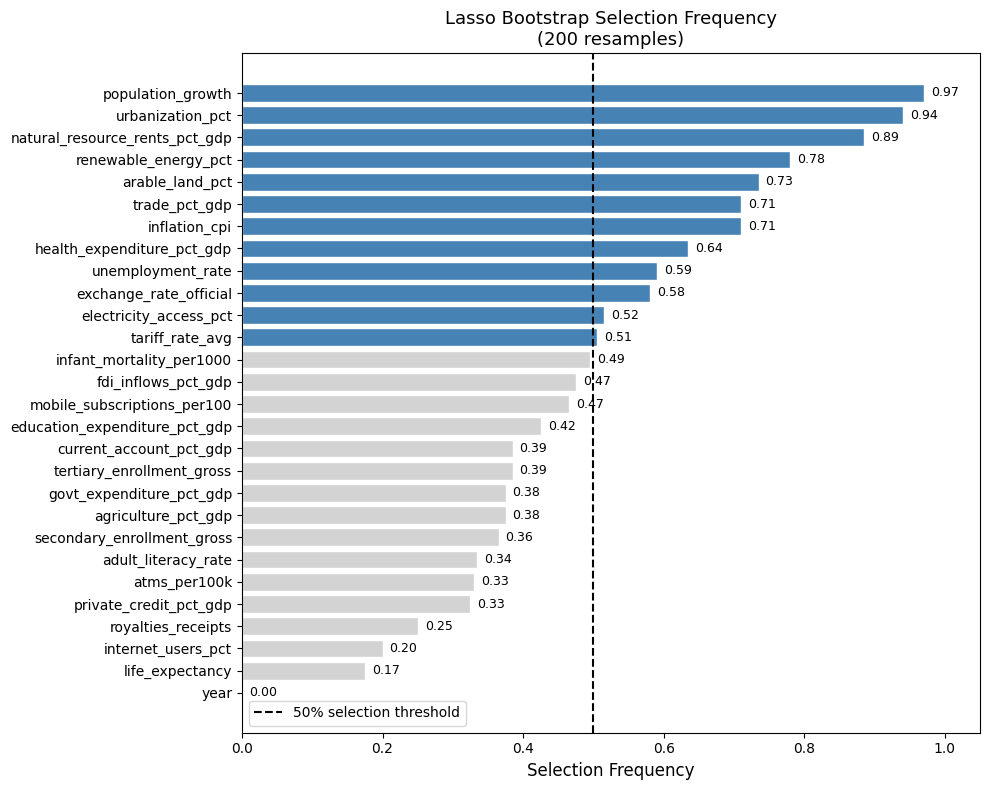


BOOTSTRAP SELECTION FREQUENCY
                       feature  frequency
             population_growth      0.970
              urbanization_pct      0.940
natural_resource_rents_pct_gdp      0.885
          renewable_energy_pct      0.780
               arable_land_pct      0.735
                 inflation_cpi      0.710
                 trade_pct_gdp      0.710
    health_expenditure_pct_gdp      0.635
             unemployment_rate      0.590
        exchange_rate_official      0.580
        electricity_access_pct      0.515
               tariff_rate_avg      0.505
      infant_mortality_per1000      0.495
           fdi_inflows_pct_gdp      0.475
   mobile_subscriptions_per100      0.465
 education_expenditure_pct_gdp      0.425
     tertiary_enrollment_gross      0.385
       current_account_pct_gdp      0.385
           agriculture_pct_gdp      0.375
      govt_expenditure_pct_gdp      0.375
    secondary_enrollment_gross      0.365
           adult_literacy_rate      0.335
   

In [115]:
n_bootstrap = 200
lasso_alphas = np.logspace(-3, 1, 100)

# --- Bootstrap ---
selection_counts = {col: 0 for col in X_train_scaled.columns}

for i in range(n_bootstrap):
    # Resample with replacement
    idx = np.random.choice(len(X_train_scaled), size=len(X_train_scaled), replace=True)
    X_boot = X_train_scaled.iloc[idx]
    y_boot = y_train.iloc[idx]

    # Fit LassoCV
    lasso_boot = LassoCV(alphas=lasso_alphas, cv=5, max_iter=10000)
    lasso_boot.fit(X_boot, y_boot)

    # Record non-zero features
    for j, col in enumerate(X_train_scaled.columns):
        if lasso_boot.coef_[j] != 0:
            selection_counts[col] += 1

    if (i + 1) % 50 == 0:
        print(f"  Bootstrap {i + 1}/{n_bootstrap} complete")

# --- Selection frequencies ---
freq_df = pd.DataFrame({
    'feature':   list(selection_counts.keys()),
    'frequency': [v / n_bootstrap for v in selection_counts.values()]
}).sort_values('frequency', ascending=True)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['steelblue' if f >= 0.5 else 'lightgray' for f in freq_df['frequency']]
ax.barh(freq_df['feature'], freq_df['frequency'], color=colors, edgecolor='white')

ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='50% selection threshold')
ax.set_xlabel('Selection Frequency', fontsize=12)
ax.set_title(f'Lasso Bootstrap Selection Frequency\n({n_bootstrap} resamples)', fontsize=13)
ax.set_xlim([0, 1.05])
ax.legend(fontsize=10)

# Annotate bars
for i, (freq, feat) in enumerate(zip(freq_df['frequency'], freq_df['feature'])):
    ax.text(freq + 0.01, i, f'{freq:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# --- Print table ---
freq_df_sorted = freq_df.sort_values('frequency', ascending=False)
print("\nBOOTSTRAP SELECTION FREQUENCY")
print("=" * 45)
print(freq_df_sorted.to_string(index=False))

Stable indicators are: natural resource rents pct, urbanization pct, population growth

Fragile indicators are: year, life expectancy, internet users pct, royalties receipts

Selection instability for these factors is telling us that there is interchangeability between factors within the same development category. For Lasso models, when faced with potentially arbitrary factors it will exclude the factors that it views as redundant.

**Prompt:** Build Python code that sweeps thresholds from 0.01 to 0.99. At each threshold, calculate total expected cost using the following formula: FN x $50B+FP x $2M where FN = false negative and FP = false positive. Plot the cost curve as a function of τ. Identify and annotate the cost-minimizing threshold.

COST-MINIMIZING THRESHOLD
Threshold (τ):       0.04
Total cost:          $70M
False Negatives:     0
False Positives:     35
Recall:              1.000
Precision:           0.239


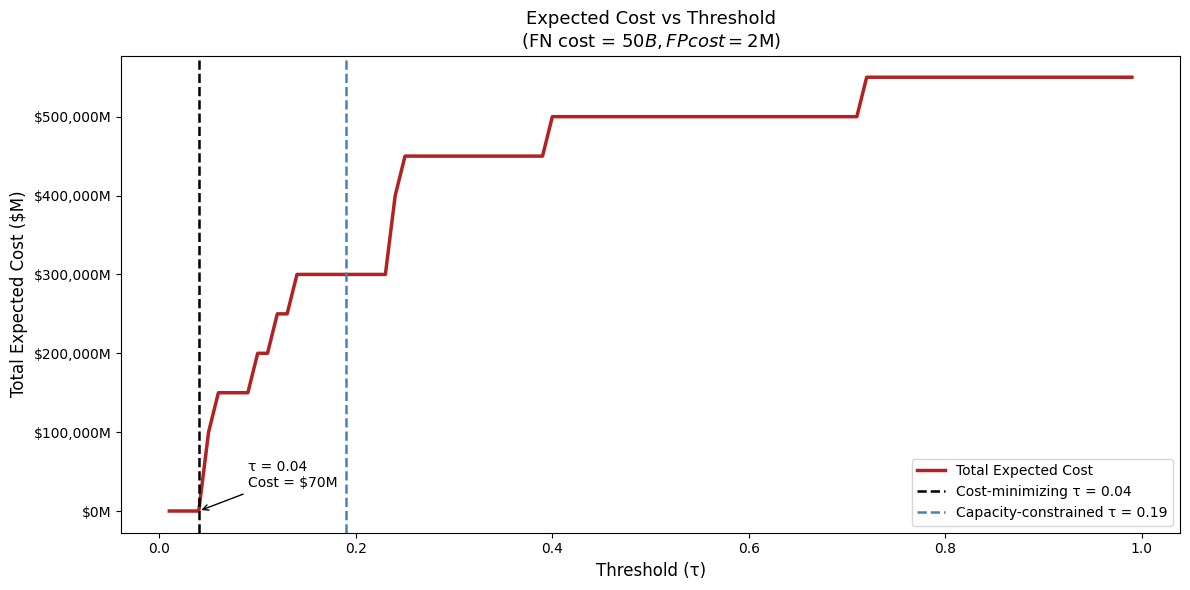

In [117]:
FN_COST = 50_000  # $50B in millions
FP_COST = 2       # $2M

import matplotlib.ticker as ticker

# --- Cost-minimizing threshold ---
min_cost_row = results_df.loc[results_df['total_cost'].idxmin()]

print("COST-MINIMIZING THRESHOLD")
print("=" * 45)
print(f"Threshold (τ):       {min_cost_row['threshold']}")
print(f"Total cost:          ${min_cost_row['total_cost']:,.0f}M")
print(f"False Negatives:     {int(min_cost_row['FN'])}")
print(f"False Positives:     {int(min_cost_row['FP'])}")
print(f"Recall:              {min_cost_row['recall']:.3f}")
print(f"Precision:           {min_cost_row['precision']:.3f}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(results_df['threshold'], results_df['total_cost'],
        color='firebrick', linewidth=2.5, label='Total Expected Cost')

# Cost-minimizing threshold
ax.axvline(min_cost_row['threshold'], color='black', linestyle='--',
           linewidth=1.8, label=f"Cost-minimizing τ = {min_cost_row['threshold']}")

# Capacity-constrained threshold
ax.axvline(tau_optimal, color='steelblue', linestyle='--',
           linewidth=1.8, label=f"Capacity-constrained τ = {tau_optimal}")

# Annotate minimum
ax.annotate(f"τ = {min_cost_row['threshold']}\nCost = ${min_cost_row['total_cost']:,.0f}M",
            xy=(min_cost_row['threshold'], min_cost_row['total_cost']),
            xytext=(min_cost_row['threshold'] + 0.05, min_cost_row['total_cost'] + 30_000),
            fontsize=10, color='black',
            arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel('Threshold (τ)', fontsize=12)
ax.set_ylabel('Total Expected Cost ($M)', fontsize=12)
ax.set_title('Expected Cost vs Threshold\n(FN cost = $50B, FP cost = $2M)', fontsize=13)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

The cost-minimizing threshold is much lower than the F1 and capacity-constrained ones from earlier. This is because there is very large asymmetry in the cost of FN versus cost of FP, and so the minimized cost threshold is going to be skewed heavily towards minimizing FN specifically. My recommendation is to use the 0.04 cost-minimizng threshold instead of the F1 one, if all else being equal and both thresholds are achievable, the goal should be to minimize cost as best as possible.